In [2]:
import numpy as np

In [3]:

data = np.load("output/latents/full_data.npz", allow_pickle=True)

mus = data['mu']
labels = data['labels']
logvars = data['logvar']


In [5]:

mus.shape, labels.shape, logvars.shape, mus.dtype, labels.dtype, logvars.dtype

((1787, 1, 512),
 (1787,),
 (1787, 1, 512),
 dtype('float32'),
 dtype('int32'),
 dtype('float32'))

In [8]:
array_squeezed = np.squeeze(mus, axis=1)

mus_flattened = array_squeezed.reshape(array_squeezed.shape[0], -1)


# Step 2: Select or manipulate to get (128, 14, 14)
# Assuming you want to discard the 256 dimension by taking one slice or reducing it
# Here, I'll take the first slice of the 256 dimension as an example
# array_reduced = array_squeezed[:, 0, :, :]  # Shape: (128, 14, 14)
# # Step 3: Flatten the last two dimensions (14*14=196) to get (128, 196)
# mus_flattened = array_reduced.reshape(128, -1)
mus_flattened.shape, mus_flattened.dtype

((1787, 512), dtype('float32'))

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
mus_pca = pca.fit_transform(mus_flattened)

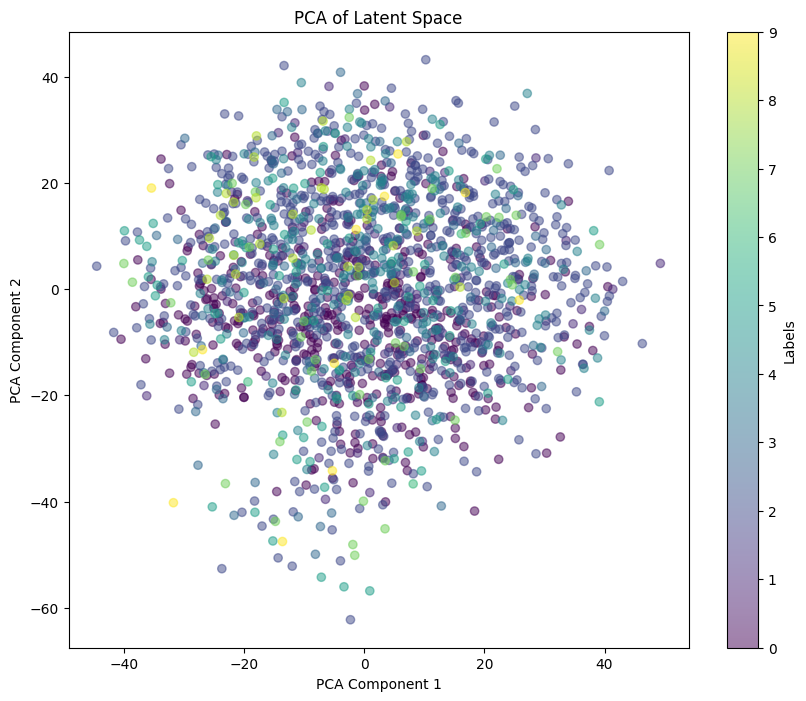

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.scatter(mus_pca[:, 0], mus_pca[:, 1], c=labels, cmap='viridis', alpha=0.5)
plt.colorbar(label='Labels')
plt.title('PCA of Latent Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

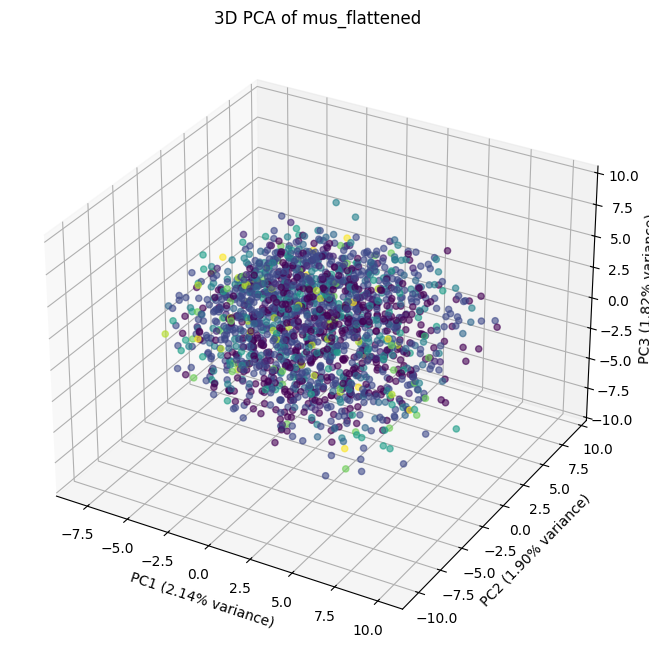

Explained variance ratios: [0.021438   0.01896347 0.01818573]
Total explained variance: 0.0585872046649456


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming mus_flattened is your input data (n_samples, n_features)
# If not already defined, you might need to load or create it
# Example: mus_flattened = np.random.rand(100, 50)  # Uncomment for testing

# Standardize the data
scaler = StandardScaler()
mus_scaled = scaler.fit_transform(mus_flattened)

# Apply PCA to reduce to 3 components
pca = PCA(n_components=3)
mus_pca = pca.fit_transform(mus_scaled)

# Create 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the 3D PCA results
scatter = ax.scatter(mus_pca[:, 0], mus_pca[:, 1], mus_pca[:, 2], c=labels, alpha=0.6)

# Set labels and title
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} variance)')
ax.set_title('3D PCA of mus_flattened')

# Optional: Add grid
ax.grid(True)

# Show plot
plt.show()

# Print explained variance ratios
print("Explained variance ratios:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))

In [12]:
# ===== VERBESSERTE VORVERARBEITUNG =====

# 1. Analysiere die Verteilung der Daten
print("=== DATENANALYSE ===")
print(f"Mus shape: {mus_flattened.shape}")
print(f"Min value: {mus_flattened.min():.4f}")
print(f"Max value: {mus_flattened.max():.4f}")
print(f"Mean: {mus_flattened.mean():.4f}")
print(f"Std: {mus_flattened.std():.4f}")

# Prüfe die Varianz pro Dimension
feature_variances = np.var(mus_flattened, axis=0)
print(f"Min feature variance: {feature_variances.min():.6f}")
print(f"Max feature variance: {feature_variances.max():.6f}")
print(f"Mean feature variance: {feature_variances.mean():.6f}")

# 2. Entferne Features mit sehr geringer Varianz
from sklearn.feature_selection import VarianceThreshold

# Entferne Features mit Varianz < 1e-6
variance_threshold = VarianceThreshold(threshold=1e-6)
mus_filtered = variance_threshold.fit_transform(mus_flattened)
print(f"Features nach Varianzfilterung: {mus_filtered.shape[1]} (von {mus_flattened.shape[1]})")

# 3. Verschiedene Skalierungsoptionen testen
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# Option A: Standard Scaling (Z-Score)
scaler_standard = StandardScaler()
mus_standard = scaler_standard.fit_transform(mus_filtered)

# Option B: Robust Scaling (weniger sensitiv zu Outliers)
scaler_robust = RobustScaler()
mus_robust = scaler_robust.fit_transform(mus_filtered)

# Option C: Min-Max Scaling
scaler_minmax = MinMaxScaler()
mus_minmax = scaler_minmax.fit_transform(mus_filtered)

print("✓ Vorverarbeitung abgeschlossen!")

=== DATENANALYSE ===
Mus shape: (1787, 512)
Min value: -27.8152
Max value: 27.4637
Mean: 0.0538
Std: 4.6269
Min feature variance: 2.004664
Max feature variance: 90.872894
Mean feature variance: 20.993362
Features nach Varianzfilterung: 512 (von 512)
✓ Vorverarbeitung abgeschlossen!


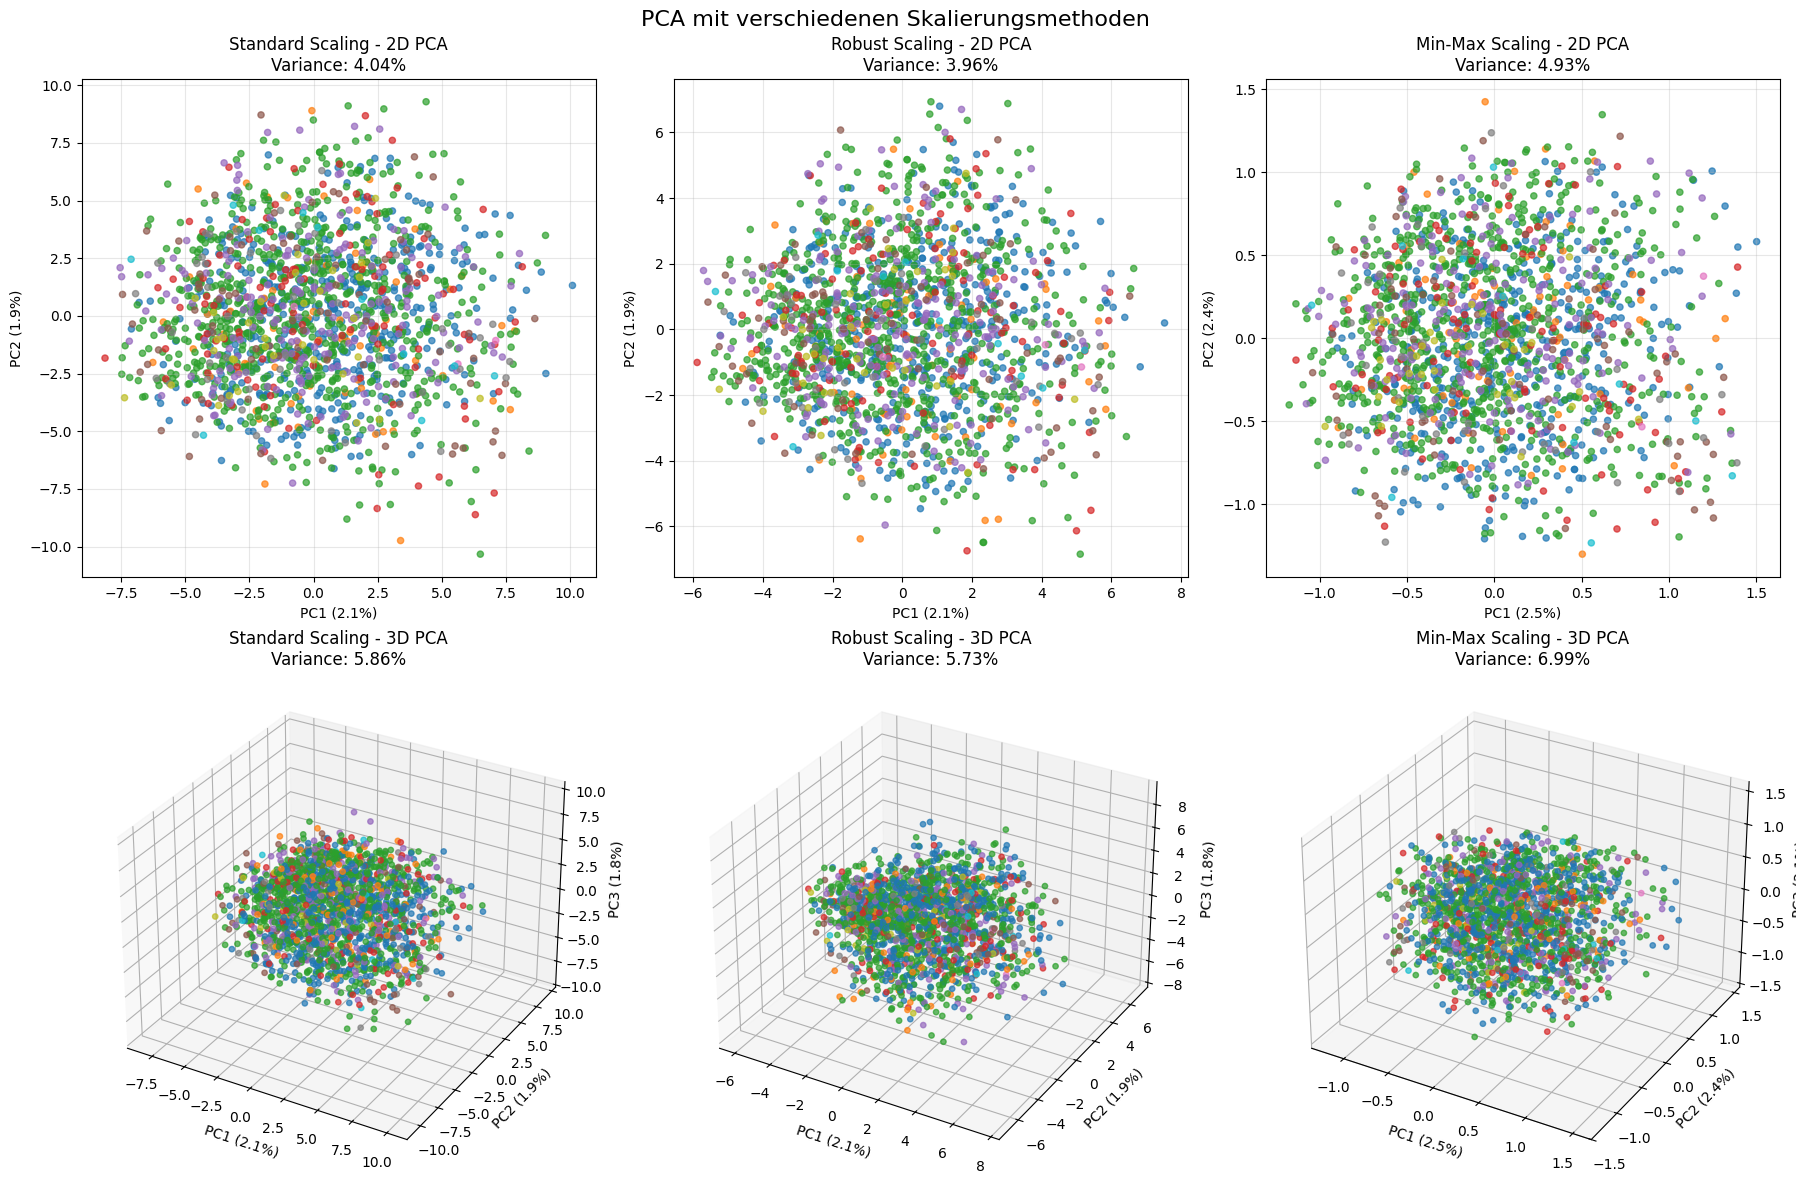

✓ Beste Skalierungsmethode: Min-Max Scaling


In [13]:
# ===== VERBESSERTE PCA UND VISUALISIERUNG =====

# Teste verschiedene Skalierungen mit PCA
scaling_methods = {
    'Standard Scaling': mus_standard,
    'Robust Scaling': mus_robust, 
    'Min-Max Scaling': mus_minmax
}

# Erstelle Subplots für Vergleich
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('PCA mit verschiedenen Skalierungsmethoden', fontsize=16)

for idx, (name, data) in enumerate(scaling_methods.items()):
    # 2D PCA
    pca_2d = PCA(n_components=2)
    data_pca_2d = pca_2d.fit_transform(data)
    
    ax1 = axes[0, idx]
    scatter = ax1.scatter(data_pca_2d[:, 0], data_pca_2d[:, 1], c=labels, cmap='tab10', alpha=0.7, s=20)
    ax1.set_title(f'{name} - 2D PCA\nVariance: {sum(pca_2d.explained_variance_ratio_):.2%}')
    ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    ax1.grid(True, alpha=0.3)
    
    # 3D PCA
    pca_3d = PCA(n_components=3)
    data_pca_3d = pca_3d.fit_transform(data)
    
    ax2 = axes[1, idx]
    ax2.remove()  # Remove 2D axis
    ax2 = fig.add_subplot(2, 3, idx+4, projection='3d')  # Add 3D axis
    
    scatter_3d = ax2.scatter(data_pca_3d[:, 0], data_pca_3d[:, 1], data_pca_3d[:, 2], 
                            c=labels, cmap='tab10', alpha=0.7, s=15)
    ax2.set_title(f'{name} - 3D PCA\nVariance: {sum(pca_3d.explained_variance_ratio_):.2%}')
    ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})')
    ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})')
    ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})')

plt.tight_layout()
plt.show()

# Zeige die beste Methode (höchste erklärte Varianz)
best_method = max(scaling_methods.keys(), 
                 key=lambda x: sum(PCA(n_components=3).fit(scaling_methods[x]).explained_variance_ratio_))
print(f"✓ Beste Skalierungsmethode: {best_method}")

PCA Preprocessing: (1787, 512) -> (1787, 50)
Erhaltene Varianz: 51.62%
Berechne t-SNE...


c:\Users\Lara\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Berechne UMAP...


c:\Users\Lara\AppData\Local\Programs\Python\Python311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


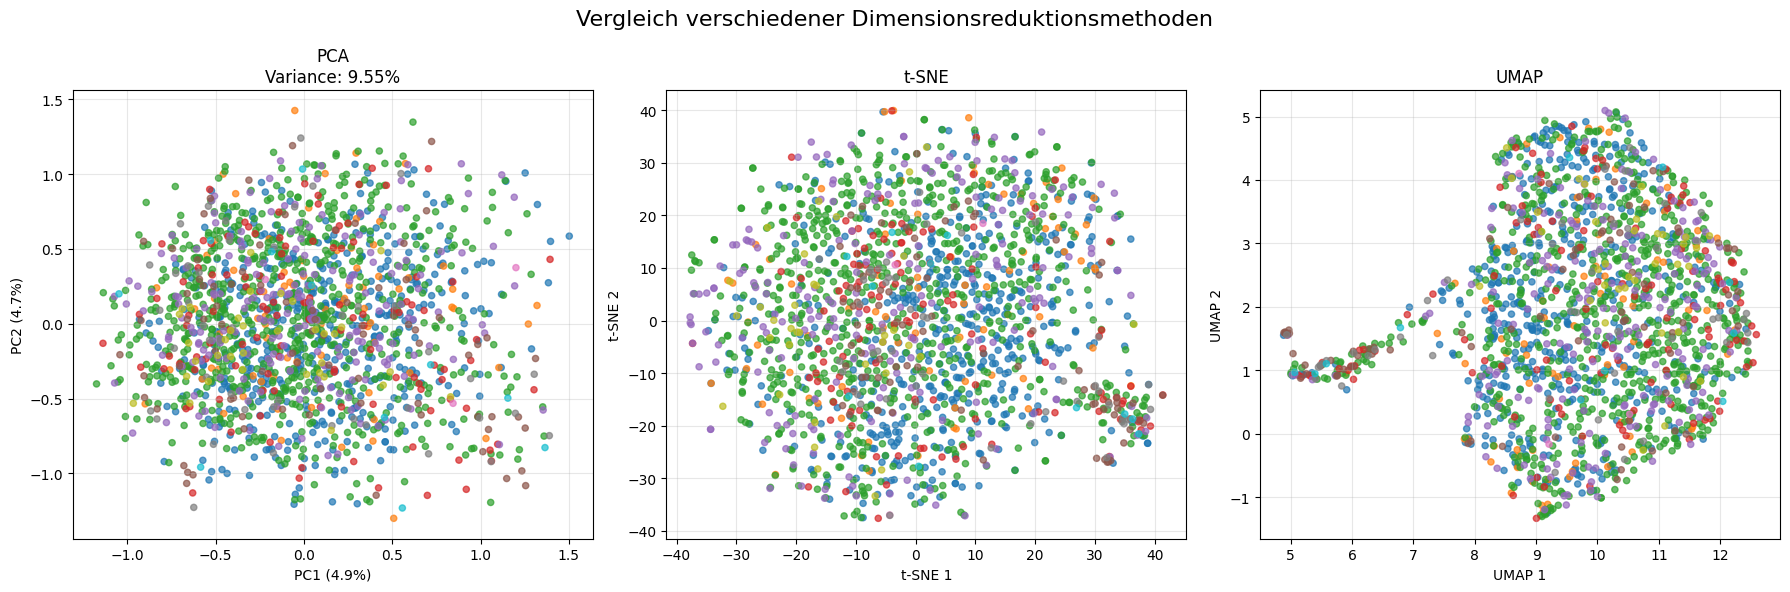

✓ Dimensionsreduktion abgeschlossen!


In [14]:
# ===== ALTERNATIVE DIMENSIONSREDUKTIONSMETHODEN =====

# Installiere benötigte Pakete falls nicht vorhanden
# !pip install umap-learn

from sklearn.manifold import TSNE
try:
    import umap
    umap_available = True
except ImportError:
    print("UMAP nicht verfügbar. Installiere mit: pip install umap-learn")
    umap_available = False

# Verwende die beste Skalierungsmethode
best_data = scaling_methods[best_method]

# Reduziere zuerst auf 50 Dimensionen mit PCA (für bessere Performance)
pca_preprocessing = PCA(n_components=min(50, best_data.shape[1]))
data_pca_prep = pca_preprocessing.fit_transform(best_data)

print(f"PCA Preprocessing: {best_data.shape} -> {data_pca_prep.shape}")
print(f"Erhaltene Varianz: {sum(pca_preprocessing.explained_variance_ratio_):.2%}")

# Verschiedene Dimensionsreduktionsmethoden
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Vergleich verschiedener Dimensionsreduktionsmethoden', fontsize=16)

# 1. PCA
pca_final = PCA(n_components=2)
data_pca = pca_final.fit_transform(data_pca_prep)

axes[0].scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='tab10', alpha=0.7, s=20)
axes[0].set_title(f'PCA\nVariance: {sum(pca_final.explained_variance_ratio_):.2%}')
axes[0].set_xlabel(f'PC1 ({pca_final.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_final.explained_variance_ratio_[1]:.1%})')
axes[0].grid(True, alpha=0.3)

# 2. t-SNE
print("Berechne t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
data_tsne = tsne.fit_transform(data_pca_prep)

axes[1].scatter(data_tsne[:, 0], data_tsne[:, 1], c=labels, cmap='tab10', alpha=0.7, s=20)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].grid(True, alpha=0.3)

# 3. UMAP (falls verfügbar)
if umap_available:
    print("Berechne UMAP...")
    umap_reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    data_umap = umap_reducer.fit_transform(data_pca_prep)
    
    axes[2].scatter(data_umap[:, 0], data_umap[:, 1], c=labels, cmap='tab10', alpha=0.7, s=20)
    axes[2].set_title('UMAP')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    axes[2].grid(True, alpha=0.3)
else:
    axes[2].text(0.5, 0.5, 'UMAP nicht verfügbar\nInstalliere mit:\npip install umap-learn', 
                ha='center', va='center', transform=axes[2].transAxes)
    axes[2].set_title('UMAP (nicht verfügbar)')

plt.tight_layout()
plt.show()

print("✓ Dimensionsreduktion abgeschlossen!")

=== LABEL-ANALYSE ===
Label 0: 489 Samples
Label 1: 77 Samples
Label 2: 727 Samples
Label 3: 117 Samples
Label 4: 203 Samples
Label 5: 80 Samples
Label 6: 3 Samples
Label 7: 45 Samples
Label 8: 35 Samples
Label 9: 11 Samples


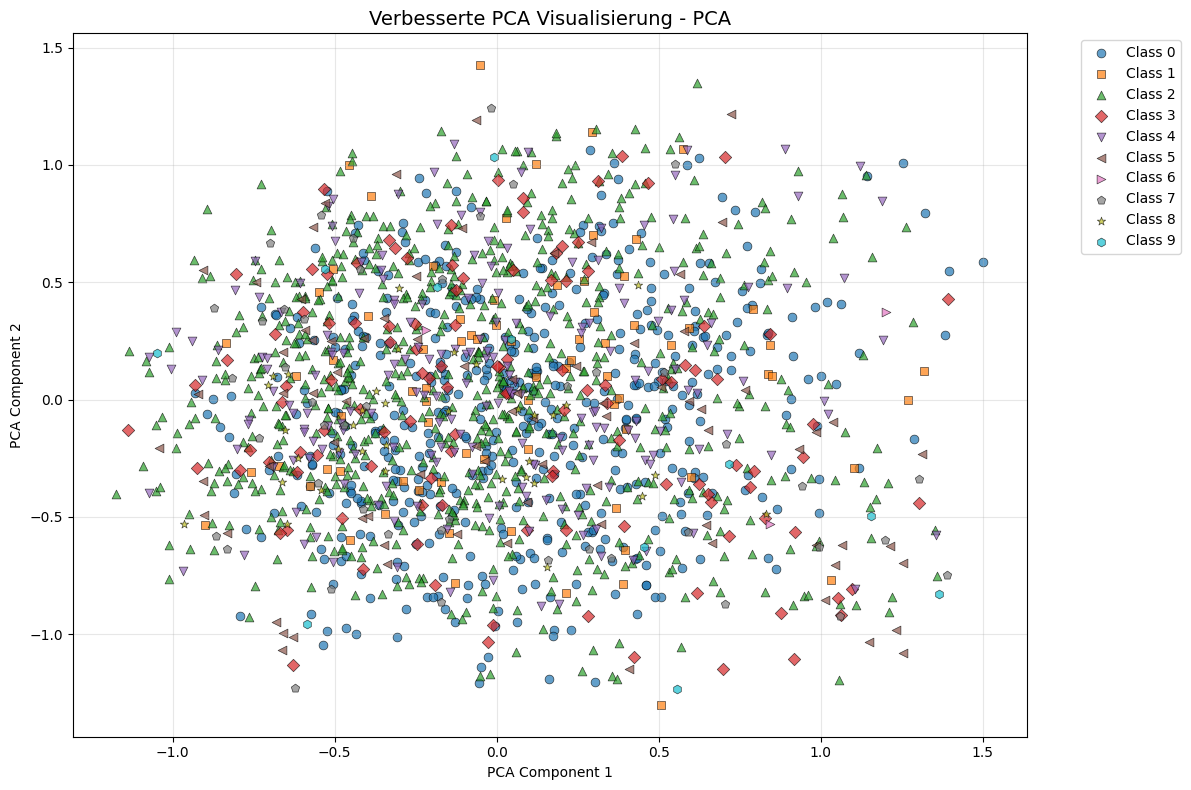

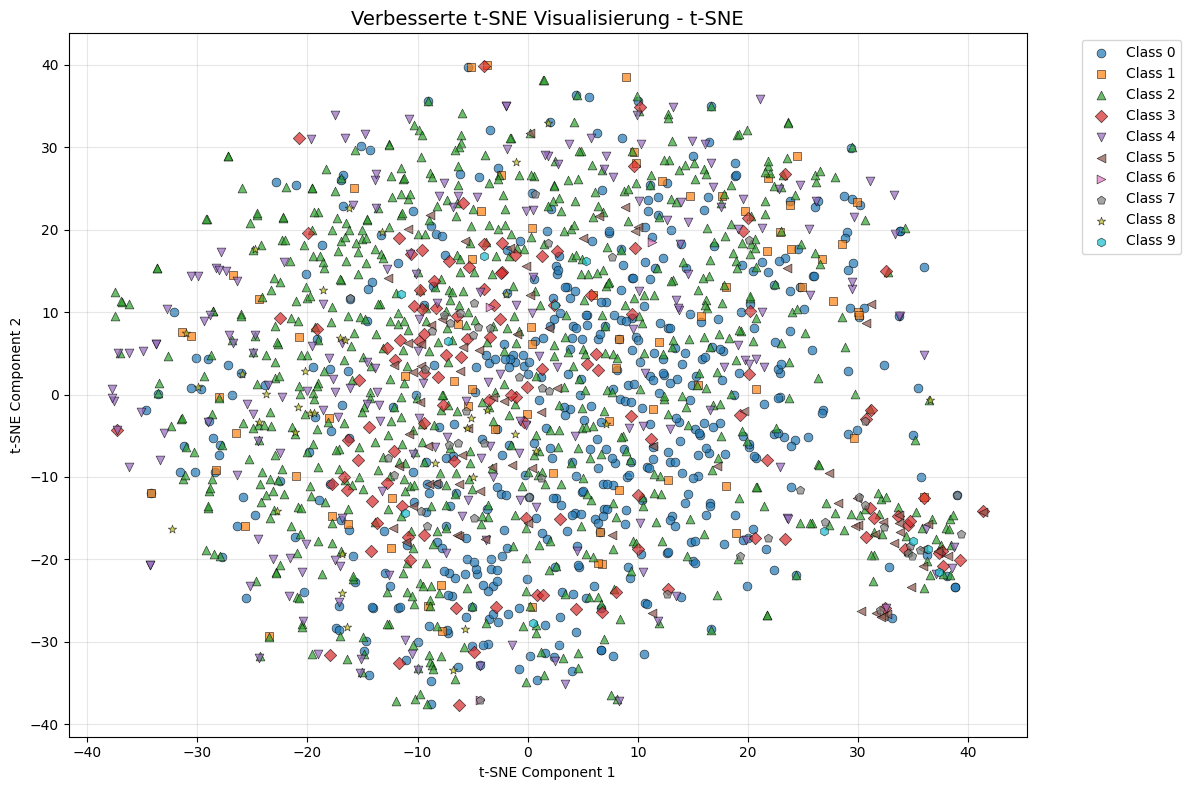

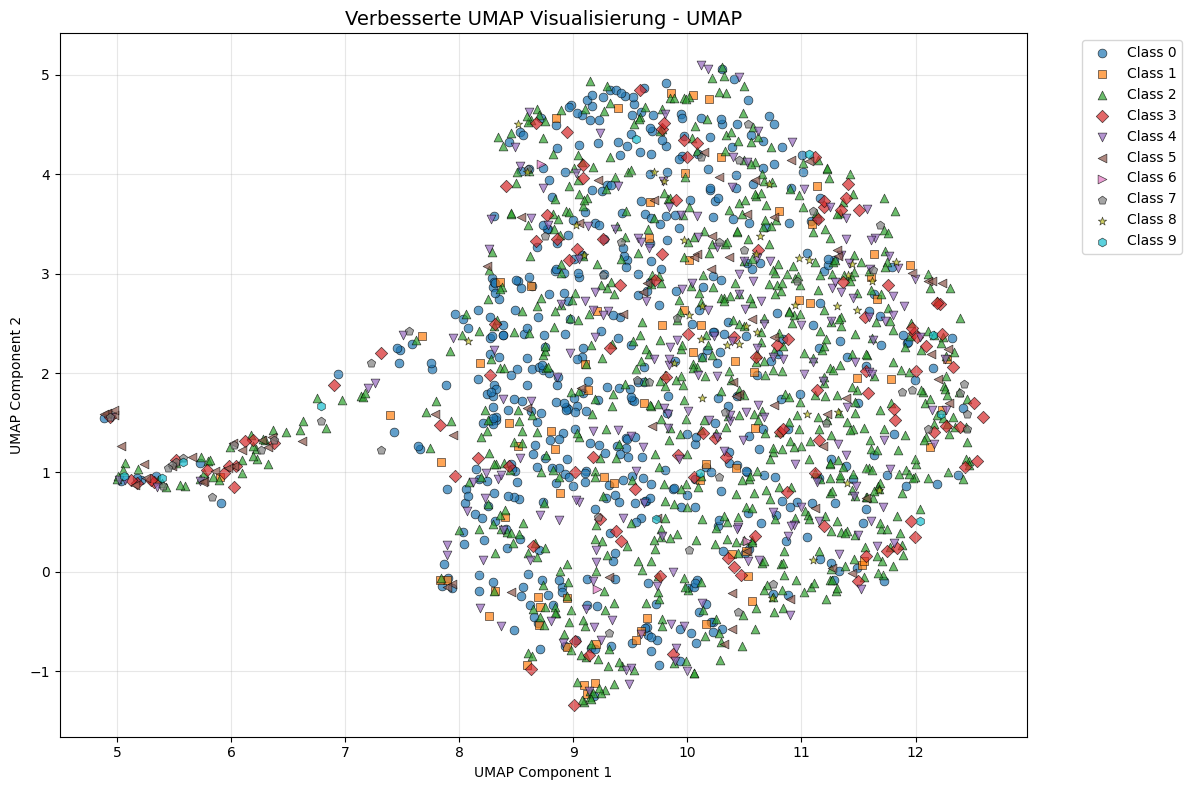


=== CLUSTER-QUALITÄT ===
PCA Silhouette Score: -0.187
PCA K-Means Silhouette Score: 0.324
t-SNE Silhouette Score: -0.144
t-SNE K-Means Silhouette Score: 0.354
UMAP Silhouette Score: -0.191
UMAP K-Means Silhouette Score: 0.383

✓ Erweiterte Analyse abgeschlossen!


In [15]:
# ===== DETAILLIERTE ANALYSE UND VERBESSERUNGEN =====

# 1. Analysiere die Labels
unique_labels, label_counts = np.unique(labels, return_counts=True)
print("=== LABEL-ANALYSE ===")
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} Samples")

# 2. Verbesserte interaktive Visualisierung mit besserer Separation
def plot_with_enhanced_separation(data_2d, labels, title, method_name):
    """Plot mit verbesserter visueller Separation"""
    plt.figure(figsize=(12, 8))
    
    # Verwende verschiedene Marker für verschiedene Labels
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x']
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for i, label in enumerate(unique_labels):
        mask = labels == label
        plt.scatter(data_2d[mask, 0], data_2d[mask, 1], 
                   c=[colors[i]], marker=markers[i % len(markers)], 
                   label=f'Class {label}', alpha=0.7, s=40, edgecolors='black', linewidth=0.5)
    
    plt.title(f'{title} - {method_name}', fontsize=14)
    plt.xlabel(f'{method_name} Component 1')
    plt.ylabel(f'{method_name} Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot die beste Methode mit verbesserter Visualisierung
plot_with_enhanced_separation(data_pca, labels, "Verbesserte PCA Visualisierung", "PCA")

if 'data_tsne' in locals():
    plot_with_enhanced_separation(data_tsne, labels, "Verbesserte t-SNE Visualisierung", "t-SNE")

if umap_available and 'data_umap' in locals():
    plot_with_enhanced_separation(data_umap, labels, "Verbesserte UMAP Visualisierung", "UMAP")

# 3. Cluster-Analyse
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

print("\n=== CLUSTER-QUALITÄT ===")
methods_to_test = [('PCA', data_pca)]
if 'data_tsne' in locals():
    methods_to_test.append(('t-SNE', data_tsne))
if umap_available and 'data_umap' in locals():
    methods_to_test.append(('UMAP', data_umap))

for method_name, data_2d in methods_to_test:
    # Silhouette Score für die tatsächlichen Labels
    silhouette = silhouette_score(data_2d, labels)
    print(f"{method_name} Silhouette Score: {silhouette:.3f}")
    
    # K-Means Clustering und Bewertung
    n_clusters = len(unique_labels)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(data_2d)
    silhouette_kmeans = silhouette_score(data_2d, cluster_labels)
    print(f"{method_name} K-Means Silhouette Score: {silhouette_kmeans:.3f}")

print("\n✓ Erweiterte Analyse abgeschlossen!")